In [ ]:
"""
Vanishing and exploding gradients are common problems in deep neural networks that occur during backpropagation.
 They make training difficult by causing gradients to become extremely small or excessively large.
Vanishing gradients slow or stop learning in earlier layers
Exploding gradients cause unstable and very large weight updates
Both problems affect convergence and model performance
Commonly seen in very deep neural networks and RNNs


Vanishing gradients occur when gradients become extremely small during backpropagation, causing earlier layers to learn very slowly or stop learning completely.
Common in deep neural networks and RNNs
Earlier layers receive very small updates
Slows down or prevents effective learning
Often caused by repeated multiplication of small gradient values

Exploding gradients occur when gradients grow too large during backpropagation, leading to unstable weight updates and divergence in loss.
When derivatives or weights are greater than 1, their repeated multiplication across layers leads to exponential growth.


Techniques to Fix Vanishing and Exploding Gradients:
1. Proper Weight Initialization
Choosing the right weight initialization keeps gradients balanced during backpropagation.
Xavier Initialization: Keeps activation variance consistent across layers to stabilize gradients.
Kaiming Initialization: Scales weights for ReLU to preserve signal strength and prevent gradient decay.

2. Use Non Saturating Activation Functions
Sigmoid and Tanh can shrink gradients. Using ReLU or its variants prevents vanishing gradients:
ReLU: Basic rectified linear unit.
Leaky ReLU: Allows small gradients for negative inputs.
ELU / SELU: Helps maintain self normalizing properties.

3. Apply Batch Normalization
Normalizes layer inputs to have zero mean and unit variance, stabilizing gradients and accelerating convergence.

4. Gradient Clipping
Limits gradients to a maximum threshold to prevent them from exploding and destabilizing training.


Effects of Vanishing and Exploding Gradients in RNNs:
Recurrent Neural Networks (RNNs) process sequences step by step, using past outputs as inputs for future steps which makes them particularly sensitive to gradient issues during training.
Causes loss of long-term memory, making earlier information difficult to retain
Large gradients can lead to unstable training and divergence
Reduces ability to learn long-range sequential dependencies
Makes optimization highly sensitive to learning rate and initialization
Advanced architectures like LSTM and GRU help stabilize gradients using gating mechanisms
Techniques such as gradient clipping, proper initialization and normalization improve training stability

"""

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [3]:
# Create a Simple Dataset

np.random.seed(42)

X = np.random.randn(2000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Define a Deep Neural Network

def build_model(activation, layers=20):
    model = Sequential()
    model.add(tf.keras.Input(shape=(2,)))
    model.add(Dense(32, activation=activation))

    for _ in range(layers - 1):
        model.add(Dense(32, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy'
    )
    return model

In [6]:
# Train Model with Sigmoid Activation

sigmoid_model = build_model('sigmoid', layers=20)

sigmoid_history = sigmoid_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [7]:
# Train Model with ReLU Activation

relu_model = build_model('relu', layers=20)

relu_history = relu_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)


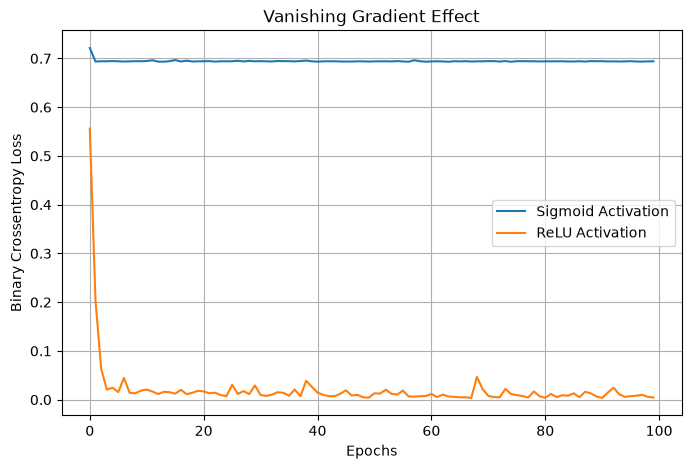

In [9]:
# Plot Training Loss Curves

plt.figure(figsize=(8,5))
plt.plot(sigmoid_history.history['loss'], label='Sigmoid Activation')
plt.plot(relu_history.history['loss'], label='ReLU Activation')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Vanishing Gradient Effect')
plt.legend()
plt.grid(True)
plt.show()